In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

# Loading the dataset

In [95]:
cols=["buying","maint","doors","persons","lug_boot","safety","class"]
df=pd.read_csv(r"E:\AI-ML LAB\car_evaluation\car.data",sep=',',header=None,names=cols)
data=df.sample(frac=1,random_state=42).reset_index(drop=True)
Attributes=cols[:-1]
Target_attribute=cols[-1]
data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,high,high,4,2,med,high,unacc
1,med,low,2,4,med,med,acc
2,high,high,5more,2,big,med,unacc
3,low,high,5more,4,med,med,acc
4,med,low,4,more,med,low,unacc


In [96]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


# Creating a default Cost of Attributes dictionary, in case we use the metric: 
# "Information Gain weighted by the cost of the attribute"

In [97]:
Cost_attributes={}
for i in Attributes:
    Cost_attributes[i]=1
Cost_attributes

{'buying': 1, 'maint': 1, 'doors': 1, 'persons': 1, 'lug_boot': 1, 'safety': 1}

# Decision Tree Classifier Implementation
**Assignment Step 1 & 2**

This class implements the ID3 Decision Tree learning algorithm as described in **Tom Mitchell's "Machine Learning" (Chapter 3)**. It is designed to be generic and supports all hyper-parameters specified in **Question 2 (a-e)** of the assignment.

---

## 1. Class Constructor & Hyper-parameters
The `__init__` method initializes the model with specific configurations required by **Question 2**.

* **`Examples`, `Attributes`, `Target_attribute`**:
    * **Step 1:** these parameters fulfill the requirement to "Prepare the dataset in desired representation" (matrix of examples, list of features, and decision class).
* **`impurity_metric`** (Default: `'entropy'`):
    * **Question 2.a:** Defines the metric for deciding the best attribute at every node. Supports:
        * `'entropy'`: (i) Entropy-based Information Gain.
        * `'gini'`: (ii) Gini Impurity Index.
        * `'gain-ratio'`: (iii) Gain-Ratio.
        * `'cost-weighted gain'`: (iv) Information Gain weighted by cost (Tom Mitchell).
* **`max_depth`** (Default: `np.inf`):
    * **Question 2.b:** "Maximum Depth of the Decision Tree." A user-defined positive integer to limit tree growth.
* **`max_impurity`** (Default: `0`):
    * **Question 2.c:** "Maximum impurity... at any node to stop further branching." A threshold [0, 1] to prevent overfitting on noisy data.
* **`train_seg`, `val_seg`** (Default: 80, 10):
    * **Question 2.d:** Defines the **Training:Validation:Testing** split ratio.
    * *Formula:* `Train_Seg : Val_Seg : (100 - Train_Seg - Val_Seg)`.
* **`replacement`** (Default: `False`):
    * **Question 2.d:** Handles the dataset partition option for sampling "with replacement" or "without replacement".
* **`percent_noise`** (Default: `0`):
    * **Question 2.e:** "Noise-percentage for evaluating robustness." Defines what percentage of attribute values in the training set are randomly flipped before training.
* **`Cost`**:
    * **Question 2.a(iv):** A dictionary of attribute costs used specifically for the **Cost-Weighted Information Gain** metric.

---

## 2. Data Preparation Methods

### `split_data(self, Examples, ...)`
* **Implements Question 2.d:** Partitions the `Examples` into Training, Validation, and Testing sets.
* **Logic:** Uses `sample()` with `frac` based on the user-defined split ratios. Supports both random sampling with and without replacement.

### `add_noise(self, Examples, ...)`
* **Implements Question 2.e:** Simulates a noisy environment to test model robustness.
* **Logic:** Iterates through the training data and randomly replaces a defined percentage (`percent_noise`) of attribute values with other valid values from the domain.

### `find_dict(self, ...)`
* **Helper for Step 2:** Creates a dictionary of all unique values for every attribute. This ensures the tree knows about all possible branches (attribute values) even if they don't appear in a specific local subset of the data during recursion.

---

## 3. Core ID3 Algorithm

### `find_entropy(self, y)` & `gini_impurity(self, y)`
* **Implements Question 2.a(i) & 2.a(ii):** Mathematical helper functions to calculate the impurity of a dataset `y` using Entropy (Log-based) or Gini Index (Probability-squared based).

### `find_best_attribute(self, ...)`
* **Implements Question 2.a:** The core logic for selecting the root node of a subtree.
* **Supported Metrics:**
    * **Entropy:** Standard Information Gain.
    * **Gini:** Impurity reduction using Gini Index.
    * **Gain Ratio:** Normalizes Gain by the *Split Information* (entropy of the attribute) to penalize attributes with too many values.
    * **Cost-Weighted:** Calculates $\frac{Gain^2}{Cost}$ (as per Tom Mitchell) to penalize expensive attributes.

### `ID3(self, ...)`
* **Implements Step 2 (The Algorithm):** Recursive function to build the decision tree.
* **Stopping Conditions:**
    1.  **Base Case:** No examples left or perfect classification (Entropy 0).
    2.  **Question 2.b:** Stops if `curr_depth >= max_depth`.
    3.  **Question 2.c:** Stops if `impurity_parent <= max_impurity`.
* **Tracking:** Updates `self.impurity_history` to track progress for plotting.

---

## 4. Evaluation & Visualization Methods

### `impurity_reduction_plot(self, ...)`
* **Implements Question 3.a:** "Plot the gradual reduction of total impurity of the training dataset after branching at every new node."
* **Logic:** Uses `matplotlib` to graph the total weighted impurity of the tree vs. the number of splits performed.

### `print_tree(self, ...)`
* **Implements Question 3.b:** "Display the final Decision Tree as Rule-Set."
* **Logic:** Recursively traverses the tree dictionary and prints logical rules (e.g., `(Outlook=Sunny) AND (Humidity=High) => No`).

### `find_all_accuracy(self, ...)`
* **Implements Question 3.c:** Calculates the final classification accuracy for Training, Validation, and Testing datasets using the fully trained model.

### `plot_accuracy(self, ...)`
* **Implements Question 3.d:** "Show how the accuracy... changes as the nodes are sequentially considered."
* **Logic:** Simulates the tree growth by training multiple trees with increasing `max_depth` (from 0 to 10) and plots the Training, Validation, and Testing accuracy curves to visualize overfitting/underfitting.

### `main(self)`
* **Driver Function:** Orchestrates the entire **Standard Set-up Experiment (Step 3)**:
    1.  Splits Data.
    2.  Adds Noise.
    3.  Trains the ID3 Model.
    4.  Generates the Impurity Plot (**Q3.a**).
    5.  Calculates Final Accuracy (**Q3.c**).
    6.  Generates the Accuracy vs. Depth Plot (**Q3.d**).

In [98]:
class DecisionTree:
    def __init__(self,Examples,Attributes,Target_attribute,impurity_metric='entropy',max_depth=np.inf,max_impurity=0,train_seg=80,val_seg=10,replacement=False,percent_noise=0,Cost=Cost_attributes):
        self.Examples=Examples
        self.Attributes=Attributes
        self.Target_attribute=Target_attribute
        self.impurity_metric=impurity_metric
        self.max_depth=max_depth
        self.max_impurity=max_impurity
        self.train_frac=train_seg/100
        self.val_frac=val_seg/100
        self.impurity_history=None
        self.replacement=replacement
        self.tree=None
        self.percent_noise=percent_noise
        self.Target_dict=None
        self.Attribute_dict={}
        self.Cost_attrb=Cost
    
    def split_data(self,Examples,train_frac=0.8,validation_frac=0.1,replacement=False):
        if(replacement):
            Examples_train=Examples.sample(frac=train_frac,random_state=42,replace=replacement)
            Examples_validation=Examples.sample(frac=validation_frac,random_state=42,replace=replacement)
            Examples_test=Examples.sample(frac=1-train_frac-validation_frac,random_state=42,replace=replacement)
        else:
            copy=Examples.sample(frac=1,random_state=42,replace=replacement)
            train=int(train_frac*copy.shape[0])
            val=int(validation_frac*copy.shape[0])
            test=copy.shape[0]-train-val
            Examples_train=copy.iloc[:train]
            Examples_validation=copy.iloc[train:train+val]
            Examples_test=copy.iloc[train+val:]
        return Examples_train,Examples_validation,Examples_test

    def add_noise(self,Examples,Attribute_dict,percent_noise=0):
        Ex_copy=Examples.copy()
        n_rows,n_cols=Ex_copy.iloc[:,:-1].shape
        for i in range(int(percent_noise*n_rows*n_cols/100)):
            rand_row=np.random.randint(0,n_rows)
            rand_col=np.random.randint(0,n_cols)
            attrb=Ex_copy.iloc[rand_row,rand_col]
            noisy_choice=np.random.choice(Attribute_dict[Ex_copy.columns[rand_col]])
            Ex_copy.iloc[rand_row,rand_col]=noisy_choice
        return Ex_copy

    def find_dict(self,Examples_train,Attributes,Target_attribute):
        Attribute_dict={}
        for at in Attributes:
            Attribute_dict[at]=Examples_train[at].unique()
        Target_dict=Examples_train[Target_attribute].unique()
        return Attribute_dict,Target_dict

    def find_entropy(self,y):
        n=y.count()
        E=0
        for i in y.unique():
            p=y.value_counts()[i]/n
            E-=p*np.log2(p)
        return E

    def gini_impurity(self,y):
        n=y.count()
        G=1
        for i in y.unique():
            p=y.value_counts()[i]/n
            G-=p**2
        return G

    def find_best_attribute(self,Examples,Target_attribute,Attributes,impurity_parent,impurity='entropy'):
        maxig=0
        best_split=None
        for j in Attributes:
            child=[]
            for i in Examples[j].unique():
                child.append(Examples[Examples[j]==i])
            IG=impurity_parent
            for i in range(len(child)):
                if(impurity=='gini'):
                    IG-=len(child[i])*self.gini_impurity(child[i][Target_attribute])/len(Examples)
                else:
                    IG-=len(child[i])*self.find_entropy(child[i][Target_attribute])/len(Examples)
            if(impurity=='gain-ratio'):
                IG/=(self.find_entropy(Examples[j])+1e-9)
            elif(impurity=='cost-weighted gain'):
                IG=(IG**2)/self.Cost_attrb[j]
            if(IG>maxig):
                best_split=j
                maxig=IG
        return best_split,maxig
    
    def pred(self,tree, car_features):
        if not isinstance(tree, dict):
            return tree   
        attribute = next(iter(tree))
        value = car_features.get(attribute)
        subtree = tree[attribute].get(value)
        return self.pred(subtree, car_features)

    def predict(self,examples,tree):
        y_pred=[]
        for i in range(len(examples)):
            y_pred.append(self.pred(tree,examples.iloc[i]))
        return y_pred
    
    def tree_dict(self,strg,tree,tempstr,flag):
        if not isinstance(tree,dict):
            strg[tree].append(tempstr)
            return
        if(flag):
            tempstr+=" AND "
        attrb=next(iter(tree))
        newtemp=tempstr+""
        for val in self.Attribute_dict[attrb]:
            sub=tree[attrb].get(val)
            newtemp+=f"({attrb}={val})"
            self.tree_dict(strg,sub,newtemp,True)
            newtemp=tempstr+""

    def print_tree(self,tree):
        strg={}
        for i in self.Target_dict:
            strg[i]=[]
        self.tree_dict(strg,tree,"",False)
        for i in self.Target_dict:
            print(f"\n\tThe class is {i} if: \n")
            flag=False
            for j in strg[i]:
                if(flag):
                    print(" OR ")
                print(f"[{j}]")
                flag=True

    def accuracy(self,y_pred,y_actual):
        return (y_pred==y_actual).sum()/len(y_actual)

    def find_all_accuracy(self,Examples_train,Examples_val,Examples_test,Target_attribute,tree):
        pred_train=self.predict(Examples_train.iloc[:,:-1],tree)
        actual_train=Examples_train[Target_attribute]
        pred_val=self.predict(Examples_val.iloc[:,:-1],tree)
        actual_val=Examples_val[Target_attribute]
        pred_test=self.predict(Examples_test.iloc[:,:-1],tree)
        actual_test=Examples_test[Target_attribute]
        accuracy_train=self.accuracy(pred_train,actual_train)
        accuracy_val=self.accuracy(pred_val,actual_val)
        accuracy_test=self.accuracy(pred_test,actual_test)
        return accuracy_train,accuracy_val,accuracy_test

    def ID3(self,Examples,Target_attribute,Attributes,Attribute_dict,impurity='entropy',max_depth=np.inf,max_impurity=0,curr_depth=0,default='Cannot be Determined'):
        if(len(Examples)==0):
            return default
        if(self.find_entropy(Examples[Target_attribute])==0):
            return Examples[Target_attribute].iloc[0]
        if(len(Attributes)==0):
            return Examples[Target_attribute].mode()[0]
        if(impurity=='gini'):
            impurity_parent=self.gini_impurity(Examples[Target_attribute])
        else:
            impurity_parent=self.find_entropy(Examples[Target_attribute])
        if(curr_depth>=max_depth or impurity_parent<=max_impurity):
            return Examples[Target_attribute].mode()[0]
        if(curr_depth==0):
            self.impurity_history=[impurity_parent*len(Examples)]
        split,gain=self.find_best_attribute(Examples,Target_attribute,Attributes,impurity_parent,impurity=impurity)
        if(split==None):
            return Examples[Target_attribute].iloc[0]
        self.impurity_history.append(self.impurity_history[-1]-len(Examples)*gain)
        curr_depth+=1
        curr=curr_depth
        tr2={}
        Attrb=Attributes.copy()
        Attrb.remove(split)
        tr2[split]={}
        for i in Attribute_dict[split]:
            tr2[split][i]=self.ID3(Examples[Examples[split]==i],
                                   Target_attribute,
                                   Attrb,
                                   Attribute_dict,
                                   impurity=impurity,
                                   curr_depth=curr,
                                   max_depth=max_depth,
                                   max_impurity=max_impurity,
                                   default=Examples[Target_attribute].mode()[0])
            curr=curr_depth
        return tr2

    def impurity_reduction_plot(self,Examples_train,impurity_history):
        N=len(Examples_train)
        nodes=np.linspace(0,len(impurity_history),num=len(impurity_history))
        plt.plot(nodes,np.array(impurity_history)/N)
        plt.xlabel("New Node Creation of Decision Tree")
        plt.ylabel("Total Impurity Values")
        plt.title("Gradual Reduction of Total Impurity on the training dataset")
        plt.show()

    def plot_accuracy(self,Examples_train,Examples_val,Examples_test):
        train_hist=[]
        val_hist=[]
        test_hist=[]
        x=min(self.max_depth,10)
        for i in range(x):
            tr=self.ID3(Examples_train,
                        self.Target_attribute,
                        self.Attributes,
                        self.Attribute_dict,
                        impurity=self.impurity_metric,
                        max_depth=i,
                        max_impurity=self.max_impurity)
            train_acc,val_acc,test_acc=self.find_all_accuracy(Examples_train,Examples_val,Examples_test,self.Target_attribute,tr)
            if(i>1):
                if(train_acc==train_hist[-1]==train_hist[-2] and test_acc==test_hist[-1]==test_hist[-2] and val_acc==val_hist[-1]==val_hist[-2]):
                    break
            train_hist.append(train_acc)
            val_hist.append(val_acc)
            test_hist.append(test_acc)
        depth=np.linspace(0,len(train_hist),num=len(train_hist))
        plt.plot(depth,train_hist,color='green',label='Training Accuracy')
        plt.plot(depth,val_hist,color='blue',label='Validation Accuracy')
        plt.plot(depth,test_hist,color='red',label='Testing Accuracy')
        plt.xlabel("Depth of the Decision Tree")
        plt.ylabel("Accuracies")
        plt.legend()
        plt.title("Accuracy Plot vs Depth of the tree")
        plt.show()
    
    def main(self):
        Examples_train,Examples_val,Examples_test=self.split_data(self.Examples,
                                                                  train_frac=self.train_frac,
                                                                  validation_frac=self.val_frac,
                                                                  replacement=self.replacement)
        self.Attribute_dict,self.Target_dict=self.find_dict(Examples_train,self.Attributes,self.Target_attribute)
        Examples_train=self.add_noise(Examples_train,self.Attribute_dict,percent_noise=self.percent_noise)
        self.tree=self.ID3(Examples_train,
                           self.Target_attribute,
                           self.Attributes,self.Attribute_dict,
                           impurity=self.impurity_metric,
                           max_depth=self.max_depth,
                           max_impurity=self.max_impurity)
        self.impurity_reduction_plot(Examples_train,self.impurity_history)
        train_acc,val_acc,test_acc=self.find_all_accuracy(Examples_train,Examples_val,Examples_test,self.Target_attribute,self.tree)
        print(f"Training Accuracy:{train_acc*100}%")
        print(f"Validation Accuracy:{val_acc*100}%")
        print(f"Test Accuracy:{test_acc*100}%")
        self.plot_accuracy(Examples_train,Examples_val,Examples_test)

# SETTINGS 0: 
- [Impurity_Metric = Entropy-based Information 
Gain], [Max_Depth = infinity], [Max_Impurity = 0], [Train_Seg = 80, Val_Seg = 10], [percentNoise = 0]

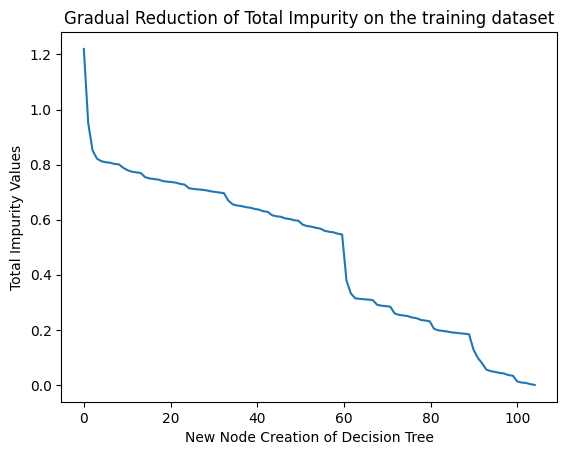

Training Accuracy:100.0%
Validation Accuracy:92.44186046511628%
Test Accuracy:91.95402298850574%


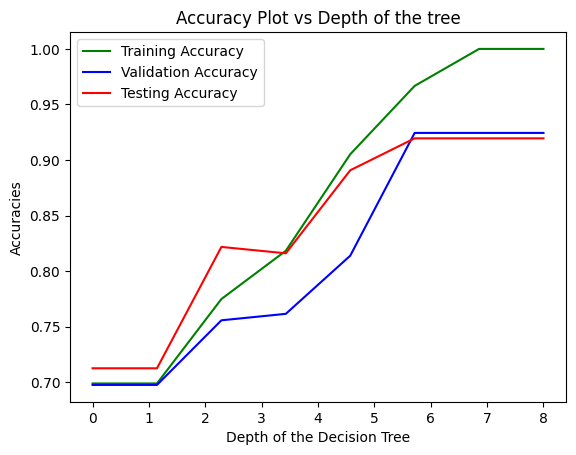

In [99]:
set0=DecisionTree(data,Attributes,Target_attribute,train_seg=80,val_seg=10,impurity_metric='entropy')
set0.main()

### Discussion on Accuracy Curves(Q3d)

The accuracy plot illustrates the performance of the Decision Tree model as it grows from a simple root node (Depth 0) to a fully expanded tree (Depth 8).

* **Learning Phase (Depth 0–6):**
    Initially, all three curves (Training, Validation, and Testing) show a strong upward trend. At shallow depths, the model is **underfitting**, meaning it is too simple to capture the underlying patterns of the data. As the tree deepens and makes more splits, it learns to classify the examples more accurately, causing a sharp rise in performance.

* **Training Accuracy (Green Curve):**
    The training accuracy continues to climb steadily until it reaches a perfect score of **100%** at Depth 7. This is expected behavior for an unpruned Decision Tree (where `max_depth` is infinite). The algorithm continues to split nodes until every leaf is pure, effectively memorizing every detail and noise in the training dataset.

* **Validation & Testing Accuracy (Blue & Red Curves):**
    Both the validation and testing accuracies improve alongside the training accuracy up to approximately Depth 6, where they plateau at around **92%**. Crucially, they stop improving even though the training accuracy continues to rise to 100%.

* **Overfitting Observation:**
    The gap that emerges between the perfect training accuracy (100%) and the plateaued validation/test accuracy (~92%) after Depth 6 indicates **overfitting**. The tree has become overly complex, creating rules that are specific only to the training data but do not generalize to new, unseen examples. This suggests that the optimal depth for this specific model and dataset is around **Depth 6**, as further complexity adds no real-world value.

# Displaying the final tree(Q3b)

In [100]:
set0.print_tree(set0.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=4)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=4)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=big) AND (maint=low)]
 OR 
[(safety=med) AND (persons=more) AND (buying=hi

- Another way of representing the tree

In [101]:
pprint(set0.tree)

{'safety': {'high': {'persons': {'2': 'unacc',
                                 '4': {'buying': {'high': {'maint': {'high': 'acc',
                                                                     'low': 'acc',
                                                                     'med': 'acc',
                                                                     'vhigh': 'unacc'}},
                                                  'low': {'maint': {'high': {'lug_boot': {'big': 'vgood',
                                                                                          'med': {'doors': {'2': 'vgood',
                                                                                                            '3': 'acc',
                                                                                                            '4': 'vgood',
                                                                                                            '5more': 'vgood'}},
                

# Similarly, the outputs for the SETTINGS 1-5 are as follows

# SETTINGS 1
- Changing Setting-0 as follows: Train_Seg = 60, Val_Seg = 20.

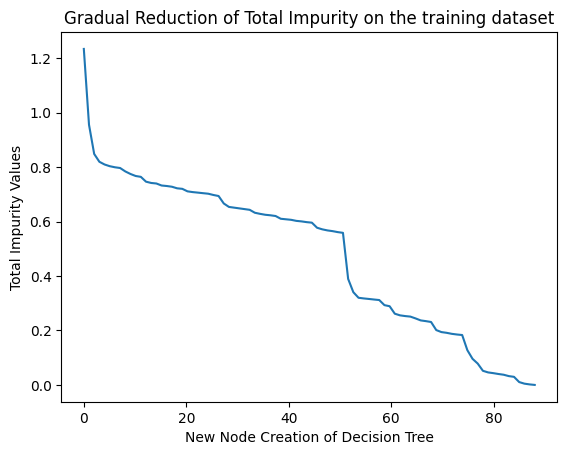

Training Accuracy:100.0%
Validation Accuracy:90.14492753623189%
Test Accuracy:90.20172910662824%


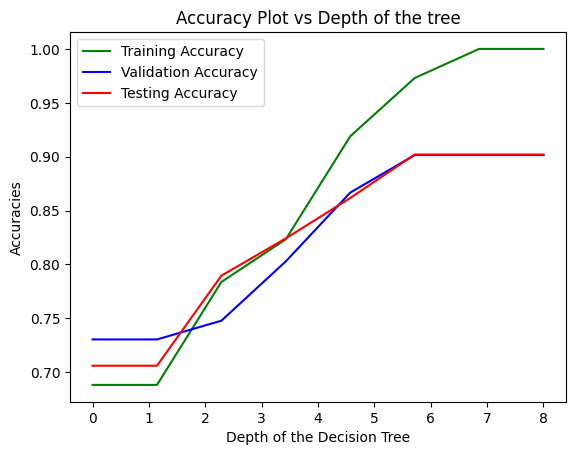

In [102]:
set1=DecisionTree(data,Attributes,Target_attribute,train_seg=60,val_seg=20)
set1.main()

In [103]:
pprint(set1.tree)

{'safety': {'high': {'persons': {'2': 'unacc',
                                 '4': {'buying': {'high': {'maint': {'high': 'acc',
                                                                     'low': 'acc',
                                                                     'med': 'acc',
                                                                     'vhigh': 'unacc'}},
                                                  'low': {'maint': {'high': {'lug_boot': {'big': 'vgood',
                                                                                          'med': {'doors': {'2': 'vgood',
                                                                                                            '3': 'acc',
                                                                                                            '4': 'vgood',
                                                                                                            '5more': 'vgood'}},
                

In [104]:
set1.print_tree(set1.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=big) AND (maint=low)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=big) AND (maint=med)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=big) AND (maint=vhigh)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=med) AND (maint=low) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=med) AND (maint=low) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (lug_boot=med) AND (maint=low) AND (doors=4)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=big) AND (maint=low)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=big) AND (maint=med)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=big) AND (maint=high)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=med) AND (maint=low) AND (d

# SETTINGS 2
-  Changing Setting-0 as follows: percentNoise = 10

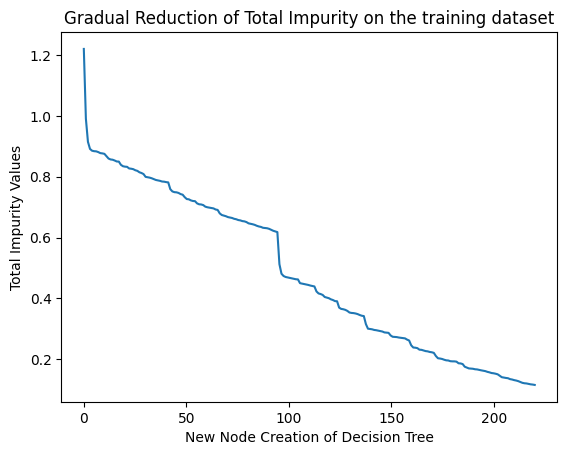

Training Accuracy:94.57308248914616%
Validation Accuracy:85.46511627906976%
Test Accuracy:86.20689655172413%


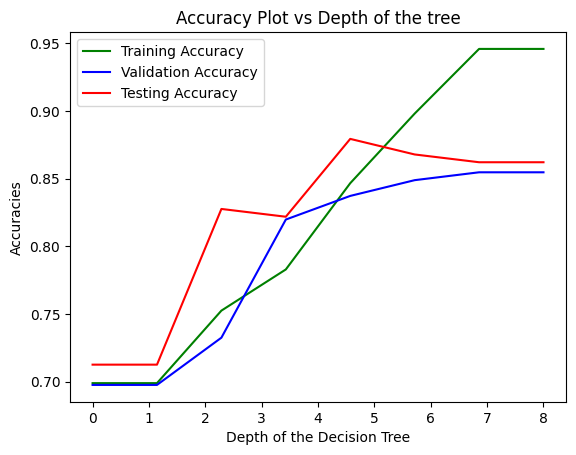

In [105]:
set2=DecisionTree(data,Attributes,Target_attribute,train_seg=80,val_seg=10,percent_noise=10)
set2.main()

In [106]:
pprint(set2.tree)

{'safety': {'high': {'persons': {'2': {'buying': {'high': {'maint': {'high': {'doors': {'2': 'unacc',
                                                                                        '3': {'lug_boot': {'big': 'unacc',
                                                                                                           'med': 'unacc',
                                                                                                           'small': 'acc'}},
                                                                                        '4': 'unacc',
                                                                                        '5more': 'unacc'}},
                                                                     'low': 'unacc',
                                                                     'med': {'doors': {'2': {'lug_boot': {'big': 'unacc',
                                                                                                          'med

In [107]:
set2.print_tree(set2.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=small) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=small)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=med)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying

# SETTINGS 3
- Changing Setting-1 as follows: percentNoise = 10 

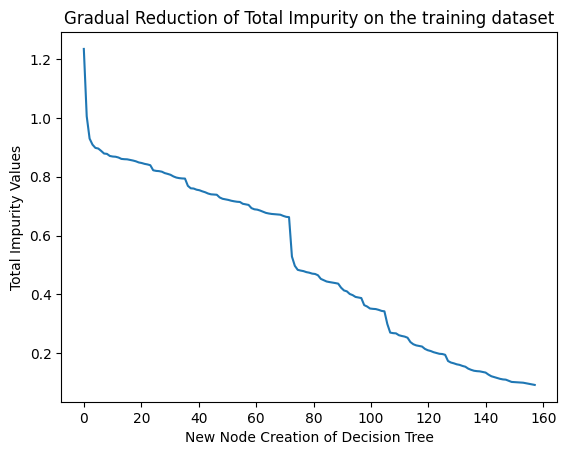

Training Accuracy:95.65637065637065%
Validation Accuracy:81.73913043478261%
Test Accuracy:83.5734870317003%


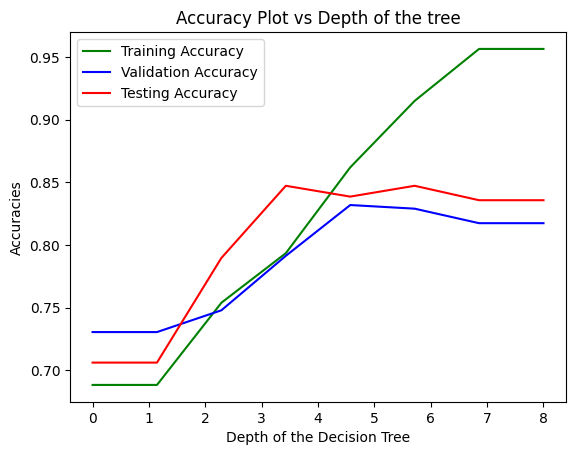

In [108]:
set3=DecisionTree(data,Attributes,Target_attribute,train_seg=60,val_seg=20,percent_noise=10)
set3.main()

In [109]:
pprint(set2.tree)

{'safety': {'high': {'persons': {'2': {'buying': {'high': {'maint': {'high': {'doors': {'2': 'unacc',
                                                                                        '3': {'lug_boot': {'big': 'unacc',
                                                                                                           'med': 'unacc',
                                                                                                           'small': 'acc'}},
                                                                                        '4': 'unacc',
                                                                                        '5more': 'unacc'}},
                                                                     'low': 'unacc',
                                                                     'med': {'doors': {'2': {'lug_boot': {'big': 'unacc',
                                                                                                          'med

In [110]:
set2.print_tree(set2.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=small) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=small)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (doors=4) AND (lug_boot=med)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying

# SETTINGS 4
- Changing Setting-0 as follows: Max_Depth = 3, Max_Impurity = 0.25 

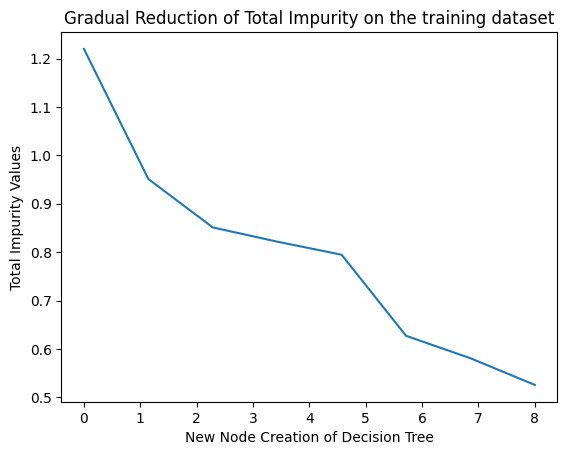

Training Accuracy:81.83791606367583%
Validation Accuracy:76.16279069767442%
Test Accuracy:81.60919540229885%


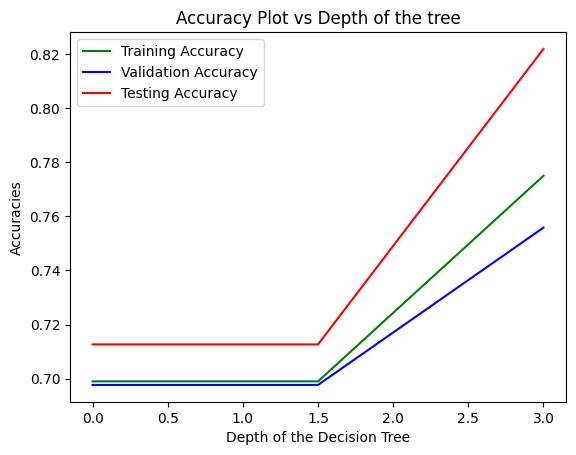

In [111]:
set4=DecisionTree(data,Attributes,Target_attribute,train_seg=80,val_seg=10,max_depth=3,max_impurity=0.25)
set4.main()

In [112]:
pprint(set4.tree)

{'safety': {'high': {'persons': {'2': 'unacc',
                                 '4': {'buying': {'high': 'acc',
                                                  'low': 'vgood',
                                                  'med': 'acc',
                                                  'vhigh': 'acc'}},
                                 'more': {'buying': {'high': 'acc',
                                                     'low': 'vgood',
                                                     'med': 'acc',
                                                     'vhigh': 'unacc'}}}},
            'low': 'unacc',
            'med': {'persons': {'2': 'unacc',
                                '4': {'maint': {'high': 'unacc',
                                                'low': 'acc',
                                                'med': 'acc',
                                                'vhigh': 'unacc'}},
                                'more': {'buying': {'high': 'unacc',
           

In [113]:
set4.print_tree(set4.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=low)]
 OR 
[(safety=med) AND (persons=more) AND (buying=med)]
 OR 
[(safety=med) AND (persons=4) AND (maint=low)]
 OR 
[(safety=med) AND (persons=4) AND (maint=med)]
 OR 
[(safety=high) AND (persons=more) AND (buying=high)]
 OR 
[(safety=high) AND (persons=more) AND (buying=med)]
 OR 
[(safety=high) AND (persons=4) AND (buying=vhigh)]
 OR 
[(safety=high) AND (persons=4) AND (buying=high)]
 OR 
[(safety=high) AND (persons=4) AND (buying=med)]

	The class is unacc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high)]
 OR 
[(safety=med) AND (persons=4) AND (maint=high)]
 OR 
[(safety=med) AND (persons=4) AND (maint=vhigh)]
 OR 
[(safety=med) AND (persons=2)]
 OR 
[(safety=high) AND (persons=more) AND (buying=vhigh)]
 OR 
[(safety=high) AND (persons=2)]
 OR 
[(safety=low)]

	The class is good if: 


	The class is vgood if: 

[(safety=high) AND (persons=more) A

# SETTINGS 5
- Changing Setting-0 as follows: Impurity_Metric = Gini impurity index

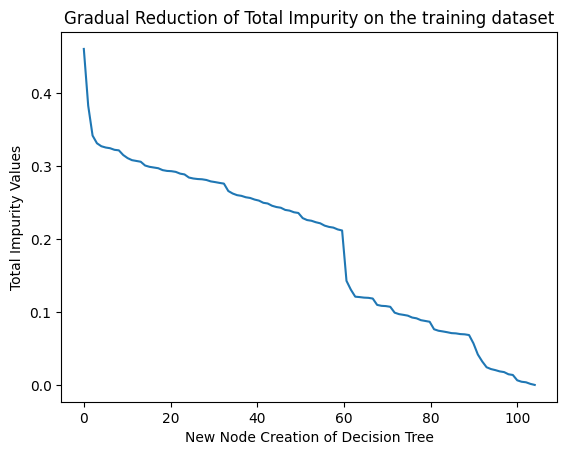

Training Accuracy:100.0%
Validation Accuracy:92.44186046511628%
Test Accuracy:91.95402298850574%


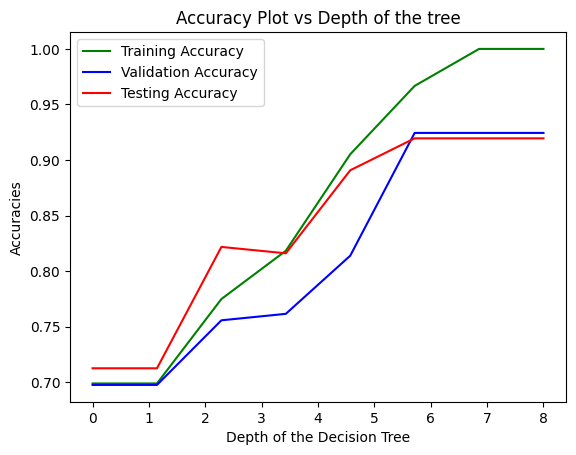

In [114]:
set5=DecisionTree(data,Attributes,Target_attribute,train_seg=80,val_seg=10,impurity_metric='gini')
set5.main()

In [115]:
pprint(set5.tree)

{'safety': {'high': {'persons': {'2': 'unacc',
                                 '4': {'buying': {'high': {'maint': {'high': 'acc',
                                                                     'low': 'acc',
                                                                     'med': 'acc',
                                                                     'vhigh': 'unacc'}},
                                                  'low': {'maint': {'high': {'lug_boot': {'big': 'vgood',
                                                                                          'med': {'doors': {'2': 'vgood',
                                                                                                            '3': 'acc',
                                                                                                            '4': 'vgood',
                                                                                                            '5more': 'vgood'}},
                

In [116]:
set5.print_tree(set5.tree)


	The class is acc if: 

[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=low) AND (lug_boot=med) AND (doors=4)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=big)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=5more)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=3)]
 OR 
[(safety=med) AND (persons=more) AND (buying=vhigh) AND (maint=med) AND (lug_boot=med) AND (doors=4)]
 OR 
[(safety=med) AND (persons=more) AND (buying=high) AND (lug_boot=big) AND (maint=low)]
 OR 
[(safety=med) AND (persons=more) AND (buying=hi

# RANDOM FOREST

In [154]:
class RandomForest:
    def __init__(self, Examples, Attributes, Target_attribute, numTrees=10, featureBagSize=None, dataBagSize=100, impurity_metric='entropy', max_depth=np.inf, max_impurity=0, train_seg=80, val_seg=10, replacement=False, percent_noise=0, Cost=None):
        
        self.Examples = Examples
        self.Attributes = Attributes
        self.Target_attribute = Target_attribute
        
        self.numTrees = numTrees
        self.featureBagSize = len(Attributes) if featureBagSize is None else featureBagSize
        self.dataBagSize = dataBagSize
        
        self.dt_params = {
            'impurity_metric': impurity_metric,
            'max_depth': max_depth,
            'max_impurity': max_impurity,
            'train_seg': train_seg,
            'val_seg': val_seg,
            'replacement': replacement,
            'percent_noise': percent_noise,
            'Cost': Cost
        }
        
        self.trees = [] #list to store the trained DT models
        self.tree_features = [] #list to store which features each tree used
        self.oob_indices = [] #list to store Out-of-Bag row indices for each tree
        
        self.Examples_train = None
        self.Examples_val = None
        self.Examples_test = None

    def bootstrap_sampling(self, train_data):
        n_rows = len(train_data)
        n_sample = int((self.dataBagSize / 100) * n_rows)
        indices = np.random.choice(n_rows, size=n_sample, replace=False)
        
        bag = train_data.iloc[indices]
        
        #keeping in account oob indices
        all_indices = np.arange(n_rows)
        oob_idx = np.setdiff1d(all_indices, indices)
        
        return bag, oob_idx

    def feature_sampling(self):
        selected_features = np.random.choice(self.Attributes, size=self.featureBagSize, replace=False)
        return list(selected_features)

    def fit(self):
        # Spliting the master dataset using the logic from DecisionTree
        # We create a dummy DT just to use its split_data method efficiently
        dummy_dt = DecisionTree(self.Examples, self.Attributes, self.Target_attribute, **self.dt_params)
        self.Examples_train, self.Examples_val, self.Examples_test = dummy_dt.split_data(
            self.Examples, 
            train_frac=self.dt_params['train_seg']/100, 
            validation_frac=self.dt_params['val_seg']/100, 
            replacement=self.dt_params['replacement']
        )
        print(f"Training Random Forest with {self.numTrees} trees:-")
        for i in range(self.numTrees):
            print(f"Training Weak Learner DT {i+1}/{self.numTrees}:-",end='\r')
            features_for_tree = self.feature_sampling()
            self.tree_features.append(features_for_tree)
            train_bag, oob_idx = self.bootstrap_sampling(self.Examples_train)
            self.oob_indices.append(oob_idx)
            #Weak Learner DT
            dt = DecisionTree(
                Examples=train_bag,
                Attributes=features_for_tree, 
                Target_attribute=self.Target_attribute,
                **self.dt_params
            )
            
            dt.Attribute_dict, dt.Target_dict = dt.find_dict(train_bag, features_for_tree, self.Target_attribute)
            dt.tree = dt.ID3(
                train_bag, 
                self.Target_attribute, 
                features_for_tree, 
                dt.Attribute_dict, 
                impurity=self.dt_params['impurity_metric'], 
                max_depth=self.dt_params['max_depth'], 
                max_impurity=self.dt_params['max_impurity']
            )
            self.trees.append(dt)
            # print(f"DT {i+1} Trained!")

    def predict_single(self, row):
        votes = []
        for i, dt in enumerate(self.trees):
            pred = dt.pred(dt.tree, row)
            votes.append(pred)
        if len(votes) == 0:
            return self.Examples[self.Target_attribute].mode()[0]
        return pd.Series(votes).mode()[0]

    def predict(self, examples):
        y_pred = []
        for i in range(len(examples)):
            y_pred.append(self.predict_single(examples.iloc[i]))
        return y_pred

    def accuracy(self, y_pred, y_actual):
        return (np.array(y_pred) == np.array(y_actual)).sum() / len(y_actual)

    def calculate_oob_accuracy(self):
        oob_accuracies = []
        for i, dt in enumerate(self.trees):
            oob_rows_indices = self.oob_indices[i]
            if len(oob_rows_indices) == 0:
                continue
                
            oob_data = self.Examples_train.iloc[oob_rows_indices]
            
            if len(oob_data) > 0:
                preds = dt.predict(oob_data.iloc[:, :-1], dt.tree)
                actuals = oob_data[self.Target_attribute]
                acc = dt.accuracy(preds, actuals)
                oob_accuracies.append(acc)
        return np.mean(oob_accuracies) if oob_accuracies else 0.0

    def analyze_attributes(self):
        root_counts = {attr: 0 for attr in self.Attributes}
        weighted_significance = {attr: 0.0 for attr in self.Attributes}

        for i, dt in enumerate(self.trees):
            if not isinstance(dt.tree, dict):
                continue
            root_attr = next(iter(dt.tree))
            if root_attr in root_counts:
                root_counts[root_attr] += 1
            
            def traverse(subtree, depth):
                if not isinstance(subtree, dict): 
                    return
                
                node_attr = next(iter(subtree))
                
                score = (self.featureBagSize - depth +1) / self.featureBagSize
                if node_attr in weighted_significance:
                    weighted_significance[node_attr] += score
                
                for val in subtree[node_attr]:
                    traverse(subtree[node_attr][val], depth + 1)

            traverse(dt.tree, 1)
            
        return root_counts, weighted_significance

    def main(self):
        self.fit()
        val_preds = self.predict(self.Examples_val.iloc[:, :-1])
        test_preds = self.predict(self.Examples_test.iloc[:, :-1])
        val_acc = self.accuracy(val_preds, self.Examples_val[self.Target_attribute])
        test_acc = self.accuracy(test_preds, self.Examples_test[self.Target_attribute])
        
        print(f"Random Forest Results for ({self.numTrees} Trees):")
        oob_acc = self.calculate_oob_accuracy()
        print(f"6a. Average OOB Accuracy: {oob_acc*100:.2f}%")
        print(f"6b. Validation Accuracy:  {val_acc*100:.2f}%")
        print(f"6b. Testing Accuracy:     {test_acc*100:.2f}%")
        
        roots, weighted = self.analyze_attributes()
        
        print("\n6c. Attribute Significance:")
        print(f"{'Attribute':<15} | {'Root Count':<10} | {'Weighted Score':<15}")
        for attr in self.Attributes:
            print(f"{attr:<15} | {roots[attr]:<10} | {weighted[attr]:.4f}")

In [157]:
rf=RandomForest(data,Attributes,Target_attribute,numTrees=50,max_depth=7,featureBagSize=5,dataBagSize=75)
rf.main()

Training Random Forest with 50 trees:-
Random Forest Results for (50 Trees):
6a. Average OOB Accuracy: 78.53%
6b. Validation Accuracy:  95.93%
6b. Testing Accuracy:     94.83%

6c. Attribute Significance:
Attribute       | Root Count | Weighted Score 
buying          | 0          | 110.6000
maint           | 0          | 174.4000
doors           | 0          | 416.0000
persons         | 3          | 54.2000
lug_boot        | 0          | 405.2000
safety          | 47         | 47.0000


### Analysis of Random Forest Results (50 Trees)

The experiment was conducted with a Random Forest of **50 trees**, using a maximum depth of **7**, feature bag size of **5**, and data bag size of **75%**.

#### 1. Performance Analysis: The Ensemble Effect
A distinct gap is observed between the **Out-of-Bag (OOB) Accuracy (78.53%)** and the final **Testing Accuracy (94.83%)**.
* **Interpretation:** The OOB score reflects the average performance of individual "weak" decision trees. The significantly higher Testing score demonstrates the power of the **Ensemble Voting mechanism**. By aggregating the predictions of 50 diverse trees, the forest corrects individual errors, reducing variance and boosting accuracy by over **16%**.

#### 2. Attribute Significance: Frequency vs. Importance
The significance metrics reveal an interesting contrast between the "most decisive" feature and the "most used" feature:
* **Dominant Root (`safety`):** The `safety` attribute was selected as the Root Node in **47 out of 50 trees**. This confirms it is the single most critical factor for classification (e.g., a car with "low" safety is likely rejected immediately).
* **High Weighted Score (`doors`, `lug_boot`):** Despite rarely being the root, attributes like `doors` (Score: 416.0) and `lug_boot` (Score: 405.2) achieved the highest weighted significance scores.
    * *Reasoning:* The metric defined in the assignment sums significance across all nodes. While `safety` is used only once at the top of a tree, `doors` and `lug_boot` are used repeatedly in deeper branches to fine-tune classifications. The metric heavily rewards this **frequency of usage** over hierarchical position.

#### 3. Conclusion
The Random Forest achieved a high generalization accuracy (approx 95%), outperforming the single Decision Tree model (approx 92% in previous steps). The "Root Count" metric correctly identified `safety` as the primary driver of the decision process, while the "Weighted Score" highlighted the utility of `doors` and `lug_boot` for handling edge cases in the data.